# 10 — QQ Rounds Ablation: Does Query-to-Query Smoothing Help?

Compares three configurations that isolate the effect of QQ (query-to-query) message passing
in Stage 3 of the AttentionESPN model.  All runs use both batching strategies
(protein-weighted MSE + gradient accumulation).

| Suffix | Features | n_qq_rounds | Notes |
|---|---|---|---|
| `both_batching` | curvature + normals + multi-agg | 2 | Full model baseline |
| `both_batching_no_qq` | curvature + normals + multi-agg | 0 | Remove QQ smoothing |
| `multi_batching_no_qq` | multi-agg only | 0 | No geometry features, no QQ |

If `both_batching_no_qq` matches `both_batching`, QQ rounds add no useful information
and may be over-smoothing the query surface.  Comparing against `multi_batching_no_qq`
shows whether geometry features (curvature + normals) still matter without QQ.

**Sections:**
1. Configuration
2. Training curves
3. Error distributions
4. Metrics comparison

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))


def show_png_grid(runs, filename, title, ncols=2):
    """Display saved PNG plots from each run's plot_dir in a grid."""
    available = [r for r in runs if (r["plot_dir"] / filename).exists()]
    if not available:
        print(f"No '{filename}' plots found. Run analyze_model.py --save-plots first.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, run in zip(axes, available):
        ax.imshow(mpimg.imread(run["plot_dir"] / filename))
        ax.set_title(run["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_metric_bars(df, title):
    """Single-panel grouped bar chart for QQ ablation runs."""
    if df.empty:
        print("No data to plot.")
        return
    metrics = [("Pearson r", "steelblue"), ("RMSE", "darkorange"), ("MAE", "seagreen")]
    n_metrics   = len(metrics)
    total_width = 0.7
    bar_w       = total_width / n_metrics
    fig, ax = plt.subplots(figsize=(9, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    x = range(len(df))
    for i, (metric, color) in enumerate(metrics):
        if metric not in df.columns or df[metric].isna().all():
            continue
        offsets = [xi - total_width / 2 + bar_w * i + bar_w / 2 for xi in x]
        bars = ax.bar(offsets, df[metric], width=bar_w, color=color, label=metric, zorder=3)
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8, rotation=90)
    ax.set_xlabel("Configuration")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df["Suffix"].tolist(), fontsize=9, rotation=15, ha="right")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

## 1. Configuration

In [3]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"
EVAL_ROOT   = THESIS_ROOT / "model_eval"

QQ_RUNS = [
    dict(
        label   = "both_batching (qq=2, baseline)",
        suffix  = "both_batching",
        plot_dir = EVAL_ROOT / "attention_both_batching",
        ckpt_dir = CKPT_ROOT / "attention_both_batching",
    ),
    dict(
        label   = "both_batching_no_qq (qq=0, full features)",
        suffix  = "both_batching_no_qq",
        plot_dir = EVAL_ROOT / "attention_both_batching_no_qq",
        ckpt_dir = CKPT_ROOT / "attention_both_batching_no_qq",
    ),
    dict(
        label   = "multi_batching_no_qq (qq=0, no geometry)",
        suffix  = "multi_batching_no_qq",
        plot_dir = EVAL_ROOT / "attention_multi_batching_no_qq",
        ckpt_dir = CKPT_ROOT / "attention_multi_batching_no_qq",
    ),
]

print(f"{'Run':<45}  {'Plots':>6}  {'Metrics':>8}")
print("-" * 65)
for r in QQ_RUNS:
    has_plots   = r["plot_dir"].exists()
    has_metrics = (r["ckpt_dir"] / "test_metrics.json").exists()
    print(f"{r['label']:<45}  {'yes' if has_plots else 'no':>6}  {'yes' if has_metrics else 'no':>8}")

Run                                             Plots   Metrics
-----------------------------------------------------------------
both_batching (qq=2, baseline)                    yes       yes
both_batching_no_qq (qq=0, full features)         yes       yes
multi_batching_no_qq (qq=0, no geometry)          yes       yes


## 2. Training Curves

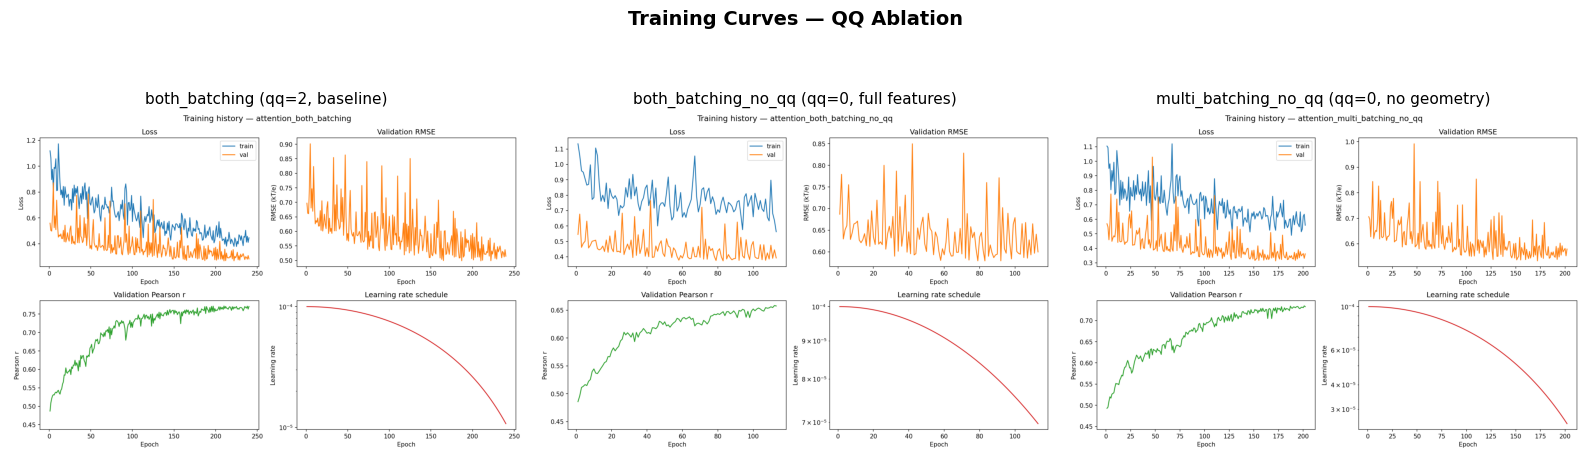

In [4]:
show_png_grid(QQ_RUNS, "training_curves.png", "Training Curves — QQ Ablation", ncols=3)

## 3. Error Distributions

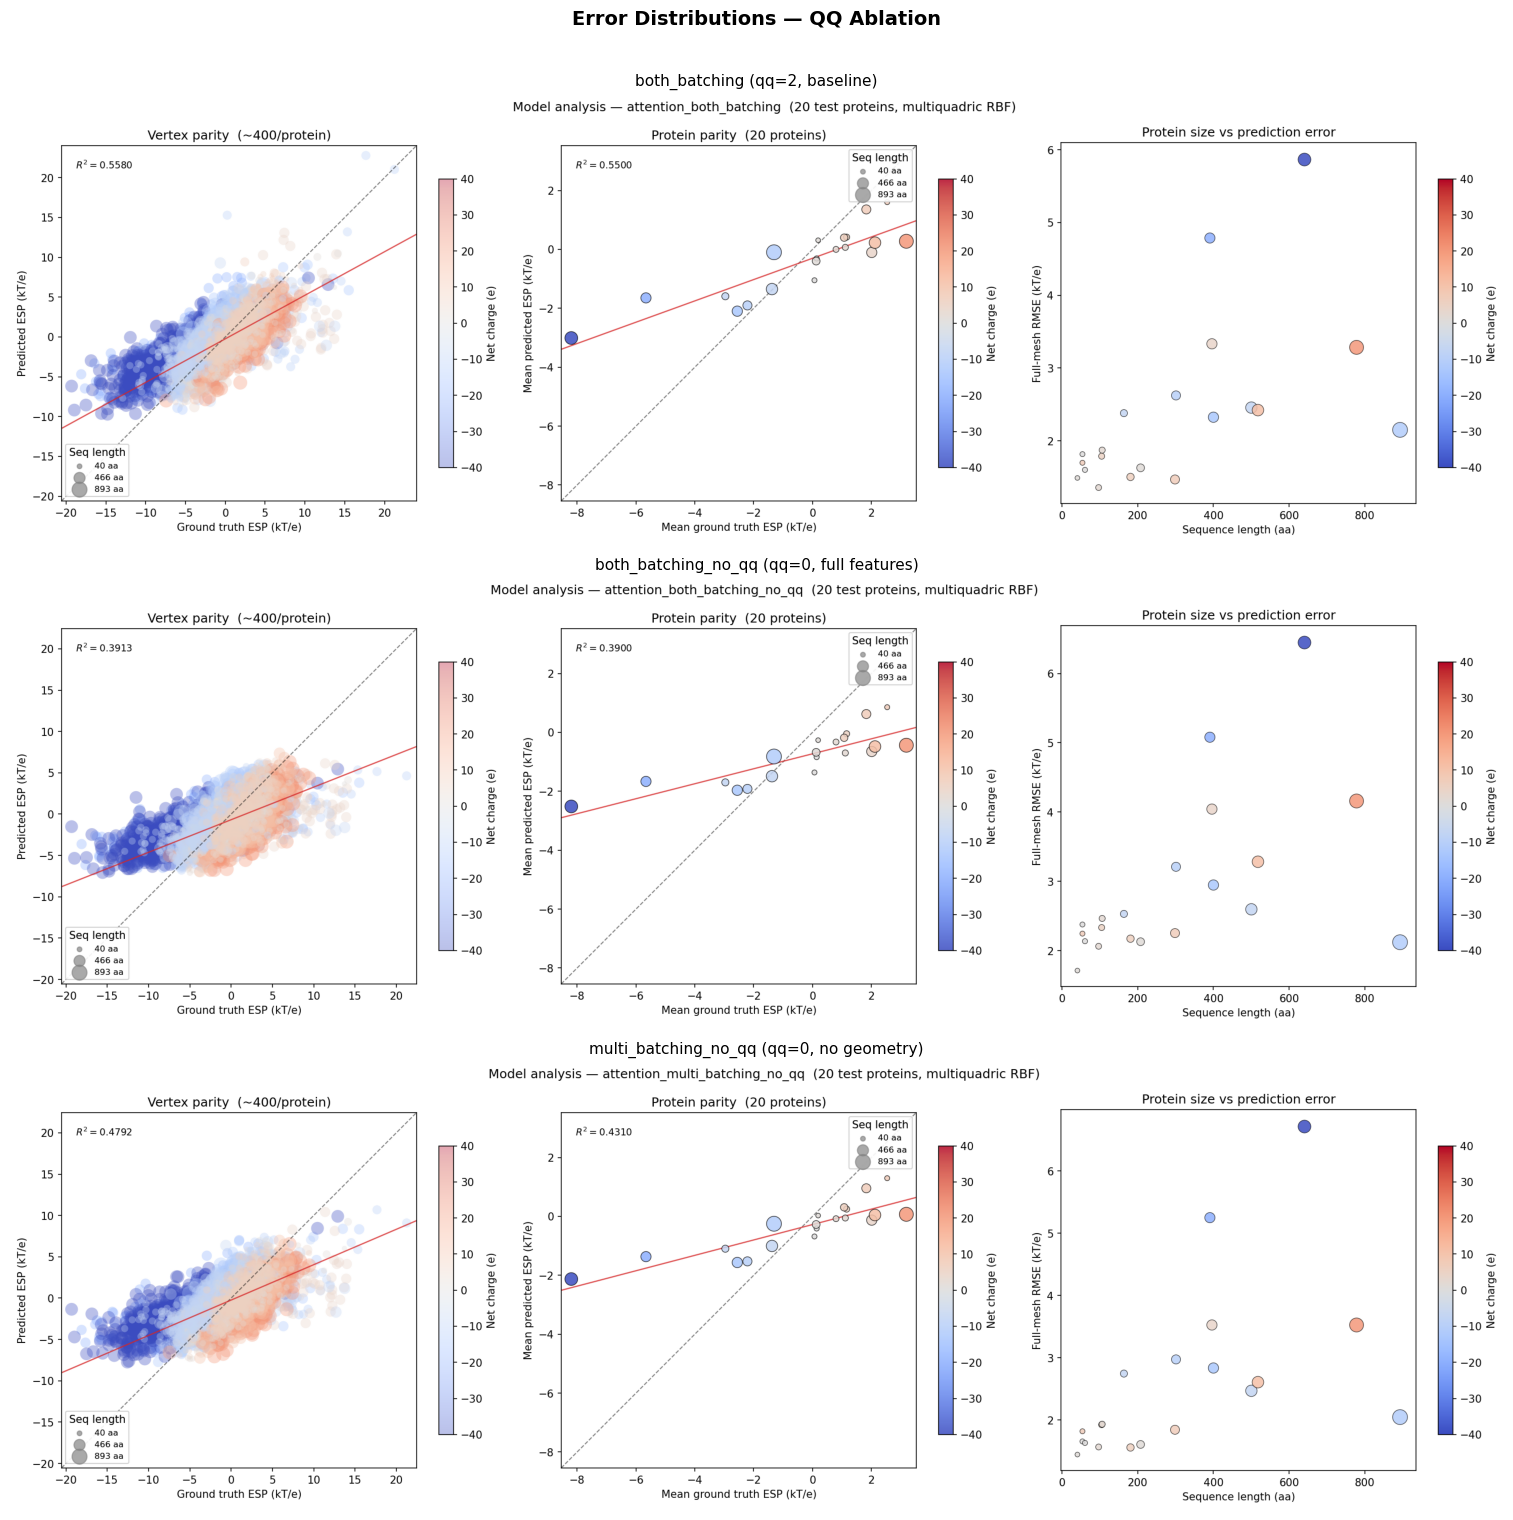

In [5]:
show_png_grid(QQ_RUNS, "error_distributions.png", "Error Distributions — QQ Ablation", ncols=1)

## 4. Metrics Comparison

In [6]:
rows_qq = []
for run in QQ_RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        print(f"  {run['label']}: test_metrics.json not found — sweep may still be running.")
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    g = data.get("global", {})
    rows_qq.append({
        "Run":            run["label"],
        "Suffix":         run["suffix"],
        "Pearson r":      g.get("pearson_r"),
        "RMSE":           g.get("rmse"),
        "MAE":            g.get("mae"),
        "Val loss":       g.get("loss"),
        "Train time (s)": g.get("train_wall_time_s"),
        "N proteins":     g.get("n_proteins"),
    })

df_qq = pd.DataFrame(rows_qq)
pd.set_option("display.float_format", "{:.4f}".format)
display(df_qq)

,Run,Suffix,Pearson r,RMSE,MAE,Val loss,Train time (s),N proteins
0,"both_batching (qq=2, baseline)",both_batching,0.7831,2.9417,2.2233,0.3575,2004.3000,20
1,"both_batching_no_qq (qq=0, full features)",both_batching_no_qq,0.6674,3.4296,2.6114,0.4977,876.1000,20
2,"multi_batching_no_qq (qq=0, no geometry)",multi_batching_no_qq,0.7479,3.1925,2.3830,0.4226,1540.7000,20


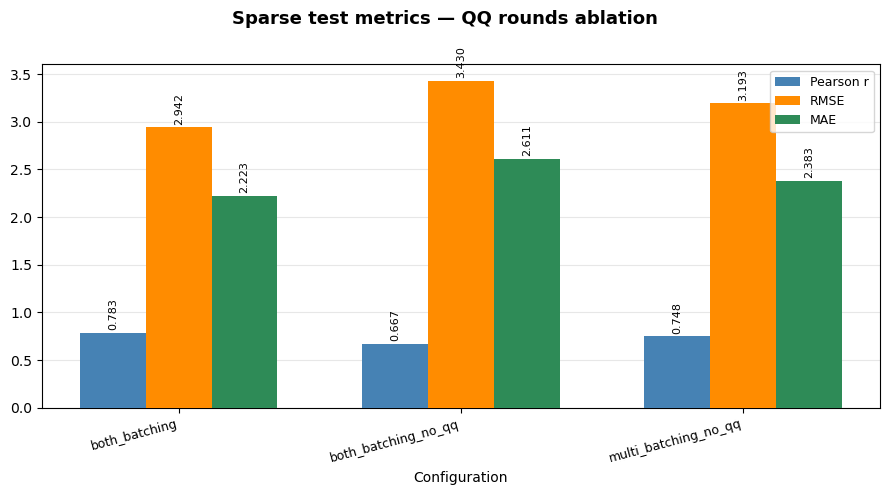

In [7]:
plot_metric_bars(df_qq, "Sparse test metrics — QQ rounds ablation")

### Full-mesh metrics

,Run,Suffix,Pearson r,RMSE,MAE,N proteins
0,"both_batching (qq=2, baseline)",both_batching,0.7815,2.9499,2.2420,20
1,"both_batching_no_qq (qq=0, full features)",both_batching_no_qq,0.6678,3.4596,2.6518,20
2,"multi_batching_no_qq (qq=0, no geometry)",multi_batching_no_qq,0.7483,3.2124,2.4142,20


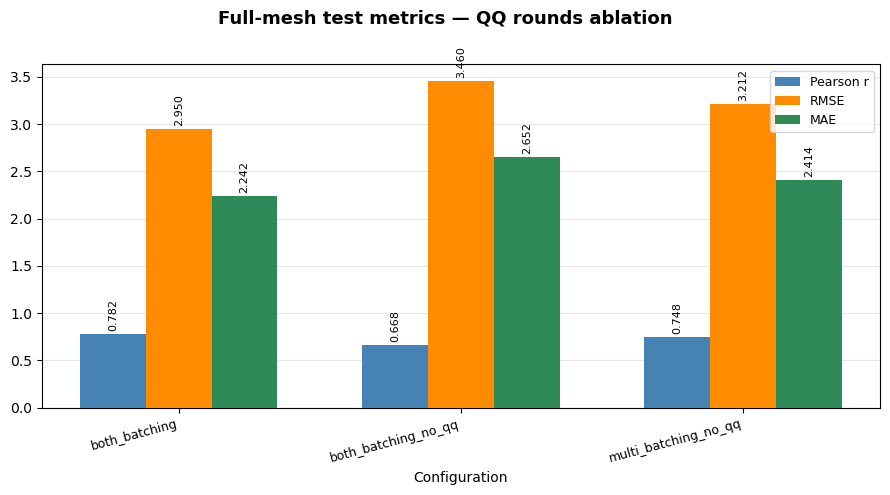

In [8]:
rows_qq_fm = []
for run in QQ_RUNS:
    fm_path = run["ckpt_dir"] / "test_metrics_fullmesh.json"
    if not fm_path.exists():
        continue
    with open(fm_path) as f:
        data = json.load(f)
    g = data.get("global", {})
    rows_qq_fm.append({
        "Run":        run["label"],
        "Suffix":     run["suffix"],
        "Pearson r":  g.get("pearson_r"),
        "RMSE":       g.get("rmse"),
        "MAE":        g.get("mae"),
        "N proteins": g.get("n_proteins"),
    })

if rows_qq_fm:
    df_qq_fm = pd.DataFrame(rows_qq_fm)
    display(df_qq_fm)
    plot_metric_bars(df_qq_fm, "Full-mesh test metrics — QQ rounds ablation")
else:
    print("No full-mesh metrics found yet.")